In [1]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt
import warnings

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance



RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
warnings.filterwarnings("ignore")
pd.options.display.max_rows = 200

In [2]:
df = pd.read_csv("cibil_score.csv")

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df.head()

,Unnamed: 0,PROSPECTID,Total_TL,Tot_Closed_TL,Tot_Active_TL,Total_TL_opened_L6M,Tot_TL_closed_L6M,pct_tl_open_L6M,pct_tl_closed_L6M,pct_active_tl,...,pct_CC_enq_L6m_of_L12m,pct_PL_enq_L6m_of_ever,pct_CC_enq_L6m_of_ever,max_unsec_exposure_inPct,HL_Flag,GL_Flag,last_prod_enq2,first_prod_enq2,Credit_Score,Approved_Flag
0,0,1,5,4,1,0,0,0.000,0.0,0.200,...,0.0,0.0,0.0,13.333,1,0,PL,PL,696,P2
1,1,2,1,0,1,0,0,0.000,0.0,1.000,...,0.0,0.0,0.0,0.860,0,0,ConsumerLoan,ConsumerLoan,685,P2
2,2,3,8,0,8,1,0,0.125,0.0,1.000,...,0.0,0.0,0.0,5741.667,1,0,ConsumerLoan,others,693,P2
3,3,4,1,0,1,1,0,1.000,0.0,1.000,...,0.0,0.0,0.0,9.900,0,0,others,others,673,P2
4,4,5,3,2,1,0,0,0.000,0.0,0.333,...,0.0,0.0,0.0,-99999.000,0,0,AL,AL,753,P1


In [6]:
df.columns = df.columns.str.lower().str.strip()

In [7]:
df.columns

Index(['unnamed: 0', 'prospectid', 'total_tl', 'tot_closed_tl',
       'tot_active_tl', 'total_tl_opened_l6m', 'tot_tl_closed_l6m',
       'pct_tl_open_l6m', 'pct_tl_closed_l6m', 'pct_active_tl',
       'pct_closed_tl', 'total_tl_opened_l12m', 'tot_tl_closed_l12m',
       'pct_tl_open_l12m', 'pct_tl_closed_l12m', 'tot_missed_pmnt', 'auto_tl',
       'cc_tl', 'consumer_tl', 'gold_tl', 'home_tl', 'pl_tl', 'secured_tl',
       'unsecured_tl', 'other_tl', 'age_oldest_tl', 'age_newest_tl',
       'time_since_recent_payment', 'time_since_first_deliquency',
       'time_since_recent_deliquency', 'num_times_delinquent',
       'max_delinquency_level', 'max_recent_level_of_deliq', 'num_deliq_6mts',
       'num_deliq_12mts', 'num_deliq_6_12mts', 'max_deliq_6mts',
       'max_deliq_12mts', 'num_times_30p_dpd', 'num_times_60p_dpd', 'num_std',
       'num_std_6mts', 'num_std_12mts', 'num_sub', 'num_sub_6mts',
       'num_sub_12mts', 'num_dbt', 'num_dbt_6mts', 'num_dbt_12mts', 'num_lss',
       'num

In [8]:
#Remove unnecessary index column if present
if 'unnamed: 0' in df.columns:
    df = df.drop(columns=['unnamed: 0'])

In [9]:
df['approved_flag'].value_counts()

approved_flag
P2    32199
P3     7452
P4     5882
P1     5803
Name: count, dtype: int64

In [10]:
#Create Binary Target
df['target_binary'] = df['approved_flag'].map({
    'P1': 1,
    'P2': 1,
    'P3': 0,
    'P4': 0
})

In [11]:
df[['approved_flag', 'target_binary']].head(10)

,approved_flag,target_binary
0,P2,1
1,P2,1
2,P2,1
3,P2,1
4,P1,1
5,P3,0
6,P1,1
7,P2,1
8,P4,0
9,P1,1


In [12]:
df['target_binary'].value_counts()

target_binary
1    38002
0    13334
Name: count, dtype: int64

In [13]:
df['target_binary'].value_counts(normalize=True) * 100

target_binary
1    74.026025
0    25.973975
Name: proportion, dtype: float64

In [14]:
#Define X and y
X = df.drop(
    columns=[
        'approved_flag',
        'target_binary',
        'credit_score',
        'prospectid'
    ],
    errors='ignore'
)

y = df['target_binary']

target_binary is our target, so it cannot be inside X.

approved_flag was used to create the target. Keeping it would create direct data leakage.

credit_score may also be closely related to how the approval category was generated, so for a clean experiment I recommend excluding it.

prospectid is just an identifier and normally should not be used for prediction.

In [15]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (51336, 84)
y shape: (51336,)


In [16]:
#Identify numerical and categorical columns
numeric_features = X.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X.select_dtypes(
    include=['object', 'category']
).columns.tolist()

In [17]:
print("Numerical features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

print("\nCategorical columns:")
print(categorical_features)

Numerical features: 79
Categorical features: 5

Categorical columns:
['maritalstatus', 'education', 'gender', 'last_prod_enq2', 'first_prod_enq2']


In [18]:
#check missing values
X.isnull().sum()[X.isnull().sum() > 0]

Series([], dtype: int64)

In [19]:
X = X.replace(-9999, np.nan)

In [20]:
#Create Numerical Preprocessing
numeric_pipeline = Pipeline(
    steps=[
        (
            'imputer',
            SimpleImputer(strategy='median')
        )
    ]
)

In [21]:
#Categorical Preprocessing
categorical_pipeline = Pipeline(
    steps=[
        (
            'imputer',
            SimpleImputer(strategy='most_frequent')
        ),

        (
            'encoder',
            OneHotEncoder(
                handle_unknown='ignore'
            )
        )
    ]
)

In [24]:
#Combine preprocessingpreprocessor = ColumnTransformer(
preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            numeric_pipeline,
            numeric_features
        ),

        (
            'cat',
            categorical_pipeline,
            categorical_features
        )
    ]
)

Numerical features
        ↓
Median imputation

Categorical features
        ↓
Most frequent imputation
        ↓
One-hot encoding

In [25]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


In [26]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting class distribution:")
print(y_test.value_counts(normalize=True))

X_train: (41068, 84)
X_test : (10268, 84)

Training class distribution:
target_binary
1    0.74026
0    0.25974
Name: proportion, dtype: float64

Testing class distribution:
target_binary
1    0.740261
0    0.259739
Name: proportion, dtype: float64


In [30]:
#Create Random Forest Binary Classifier
rf_classifier = Pipeline(
    steps=[
        (
            'preprocessor',
            preprocessor
        ),

        (
            'model',
            RandomForestClassifier(
                n_estimators=200,
                max_depth=10,
                min_samples_split=5,
                min_samples_leaf=2,
                max_features='sqrt',
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)


n_estimators=200
Create 200 Decision Trees 

Tree 1 ─┐
Tree 2 ─┤
Tree 3 ─┤
...     ├── Majority vote → Final prediction
Tree 200┘

For classification, each tree gives a class prediction and Random Forest combines their votes.

max_depth=10

Each tree can grow to a maximum depth of 10.

This prevents trees from becoming extremely complex.

Too deep
→ memorization
→ high variance
→ overfitting

min_samples_split=5

A node must contain at least 5 observations before it can split.

min_samples_leaf=2

Each final leaf must contain at least 2 observations.

This also reduces overfitting.

max_features='sqrt'

At each split, Random Forest randomly considers approximately:

$$ \sqrt{\text{number of features}} $$

rather than all features.

For example:

100 features
↓
sqrt(100)
↓
10 features considered at a split

This makes trees more diverse.

In [31]:
#Train the Random Forest
rf_classifier.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](84,)","['total_tl','tot_closed_tl','tot_active_tl',...,'gl_flag','last_prod_enq2', 'first_prod_enq2']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,84
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainde

What happens internally?
X_train
   ↓
Missing-value treatment
   ↓
One-Hot Encoding
   ↓
Random Forest
   ↓
200 Decision Trees trained

In [32]:
#Make Predictions
y_pred = rf_classifier.predict(
    X_test
)

y_pred contains values such as:

[1, 0, 1, 1, 0, 0, 1, ...]

Each value is the predicted binary class.

In [33]:
#Predicted Probabilities

y_prob = rf_classifier.predict_proba(
    X_test
)[:, 1]

In [34]:
#Accuracy
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

Accuracy: 0.8742695753798208


Interpretation:

The Random Forest correctly classified approximately 87% of test observations.

In [35]:
#Precision
precision = precision_score(
    y_test,
    y_pred
)

print("Precision:", precision)

Precision: 0.8913420987348053


It means:

Out of all observations predicted as class 1, approximately 89% actually belonged to class 1

In [36]:
#Recall
recall = recall_score(
    y_test,
    y_pred
)

print("Recall:", recall)

Recall: 0.9454019207998947


It means:

Out of all actual class-1 observations, approximately 94% were correctly detected.

In [37]:
#F1 Score
f1 = f1_score(
    y_test,
    y_pred
)

print("F1 Score:", f1)

F1 Score: 0.917576454063717


Higher is generally better.

In [38]:
#ROC-AUC
roc_auc = roc_auc_score(
    y_test,
    y_prob
)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.9245031550374715


In [39]:
#Print All Results Together
print("Random Forest Binary Classifier")

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC-AUC  :", roc_auc)

Random Forest Binary Classifier
Accuracy : 0.8742695753798208
Precision: 0.8913420987348053
Recall   : 0.9454019207998947
F1 Score : 0.917576454063717
ROC-AUC  : 0.9245031550374715


In [40]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.81      0.67      0.74      2667
           1       0.89      0.95      0.92      7601

    accuracy                           0.87     10268
   macro avg       0.85      0.81      0.83     10268
weighted avg       0.87      0.87      0.87     10268



In [41]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[1791  876]
 [ 415 7186]]


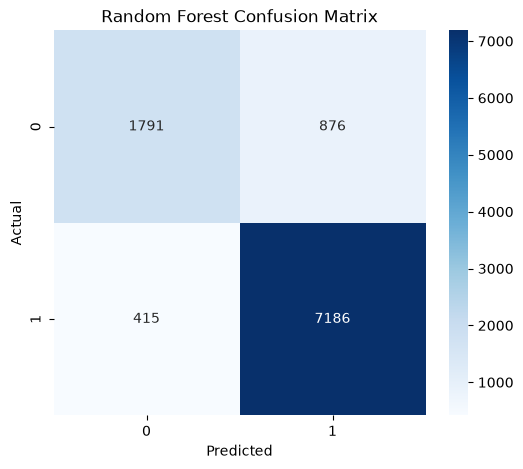

In [42]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

In [43]:
train_accuracy = rf_classifier.score(
    X_train,
    y_train
)

test_accuracy = rf_classifier.score(
    X_test,
    y_test
)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy :", test_accuracy)

Training Accuracy: 0.9110012661926561
Testing Accuracy : 0.8742695753798208


In [44]:
feature_names = (
    rf_classifier
    .named_steps['preprocessor']
    .get_feature_names_out()
)

In [45]:
importance = (
    rf_classifier
    .named_steps['model']
    .feature_importances_
)

In [46]:
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

In [47]:
feature_importance = (
    feature_importance
    .sort_values(
        by='Importance',
        ascending=False
    )
)

feature_importance.head(15)

,Feature,Importance
61,num__enq_l3m,0.131103
60,num__enq_l6m,0.078815
23,num__age_oldest_tl,0.063995
58,num__time_since_recent_enq,0.061850
74,num__pct_pl_enq_l6m_of_ever,0.050884
72,num__pct_pl_enq_l6m_of_l12m,0.046248
59,num__enq_l12m,0.040772
27,num__time_since_recent_deliquency,0.038951
56,num__pl_enq_l6m,0.037804
38,num__num_std,0.027302


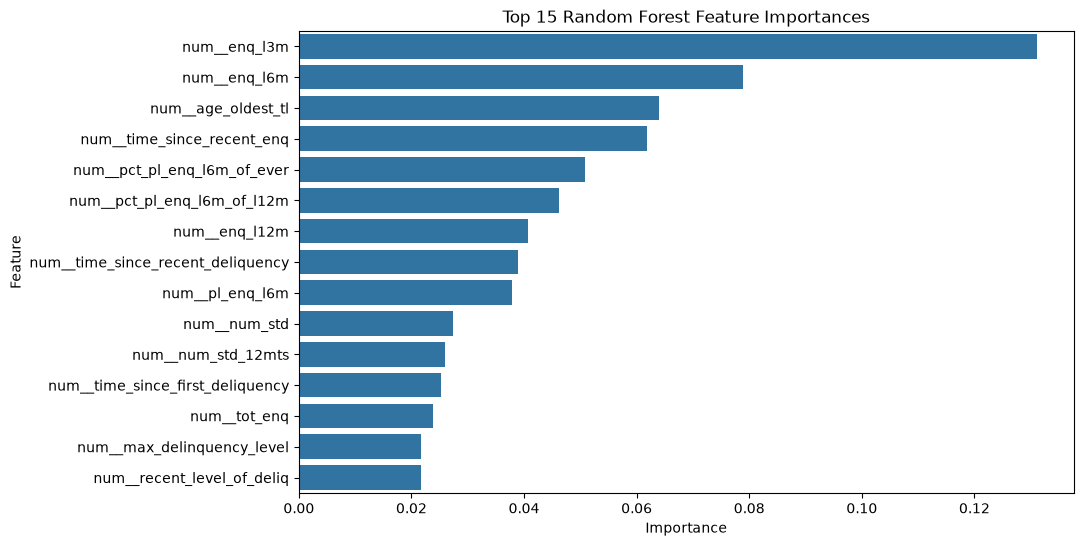

In [48]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features,
    x='Importance',
    y='Feature'
)

plt.title(
    "Top 15 Random Forest Feature Importances"
)

plt.show()

The Random Forest Binary Classifier achieved a test accuracy of 87.43%,
precision of 89.13%, recall of 94.54%,
F1-score of 91.76%, and ROC-AUC of 92.45%.
The high recall indicates that the model successfully identified most of the positive-class observations, 
while the high precision shows that most positive predictions were correct. 
The difference between training accuracy (91.10%) and testing accuracy (87.43%) was relatively small, 
indicating that the model generalized well and did not exhibit severe overfitting. 
The ROC-AUC score of 0.9245 further indicates strong discrimination between the two classes.

However, the confusion matrix shows 876 false positives compared with 415 false negatives. Therefore, the model is more inclined to classify observations as the positive class. This is consistent with the high recall and slightly lower precision.